# AutoRegressive Integrated Moving Average (ARIMA) model


## Prerequisites:

To start Auto-regressive Integrated Moving Average (ARIMA) model, you must have proper understanding of a few basic concepts:

- Time Series data  
- Auto-Regressive (AR) model
- Moving Average (MA) model
- Auto-Regressive Moving Average (ARMA) model


## Learning Objective:

- Understand the concept of ARIMA model, its mathematical notation, and data generation process. 

- Apply ARIMA(p, d, q) model on synthetic data using `statsmodels`.


## Introduction to ARIMA Model

The ARMA model handles stationary data only. It cannot handle data with trends. To fit data with the trend, we need to remove the trend present to make it stationary, which can be done with differencing, as shown in Data Pre-processing (chapter 1.3). And then only, we can fit the ARMA model on thus generated stationary data. The fitted ARMA model can be used to forecast the differenced data, and then the forecasted data can be converted back to the original pattern with the inverse differencing operation. Well, this inverse differencing operations are added explicit work for ARMA models. **Why not make a model that does this task of inverse differencing implicitly?**

The result is the ARIMA model that can handle data with trends. The ARIMA model has added **I** part, which stands for Integrated. The term Integrated comes from inverse differencing, which results in cumulative sums. Thus, the ARIMA has three parts - AR, MA, and differencing parts.




### Mathematical Expression for ARIMA(p, d, q) Model
$\newcommand{\line}{\rule{4cm}{0.4pt}}$

$X_t$ is generated by an ARIMA(p, d, q) process if
$$
X^\prime_t = \nabla^d X_t \line (1) 
$$ 
is generated by an ARMA(p, q) process.

i.e. 

>$$
\begin{align*}
X^\prime_t 
&= \phi_1 X^\prime_{t-1}+ \phi_2 X^\prime_{t-2} + .... + \phi_p X^\prime_{t-p} +   Z_t + \theta_1 Z_{t-1} + \theta_2 Z_{t-2}+ .... + \theta_q Z_{t-q} \\
&= \sum_{i=1} ^p {\phi_i X^\prime_{t-i}} + Z_t + \sum_{i = 1} ^q {\theta_i Z_{t - i}}\\ 
\end{align*}
\\ 
\text{or}, 
\\
\phi(B) X_t ^\prime = \theta(B) Z_t \line (2)$$





where,
* $\nabla$ is a difference operator, $\nabla = 1 - B$ where $B$ is a backward operator. 
    * $\nabla X_t = (1- B) X_t = X_t - X_{t-1}$

* $p$ is the order of AR-part, and $q$ is the order of the MA-part.

* $d$ is the order of Differencing.

* $\phi_1, ..., \phi_p$ are AR-part model parameters and $\theta_1, ..., \theta_q$ are MA-part model parameters. 

* $\phi(B) = 1 - \sum_{i=1} ^p \phi_i B^i$ is operation for AR-part 

* $\theta(B) = 1 + \sum_{i = 1} ^q \theta_i B^i$ is operation for MA-part

* $Z_t$ is white noise introduced at current time $t$.

\\

Combining equations (1) and (2), we can use a simplified notation for ARIMA(p, d, q) process, which is given below. 

$$
\begin{align*}
\phi_p(B) \nabla ^d X_t &= \theta_q(B) Z_t
\end{align*}
$$



### Link with previous Processes

1. ARIMA(p, 0, q) = ARMA (p, q)

2. ARIMA(p, 0, 0) = AR(p)

3. ARIMA(0, 0, q) = MA(q)



## Example 

Let's take the example of an ARIMA(3, 1, 3) model. The following two equations define the dataset X generated by the model. 

$$\nabla X_t = X^\prime_t$$

and

$$ X^\prime_t = 0.2 X^\prime_{t - 1} + 0.15 X^\prime_{t - 2} + 0.1 X^\prime_{t - 3} + Z_t + 0.4 Z_{t - 1} + 0.2 Z_{t - 2} + 0.1 Z_{t - 3}$$

\\

Next, we build an ARMA process and generate the time series data using the ARMA process. And we will use this data to create cumulative sums so that data will have a trend. 


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

from scipy import optimize
from statsmodels.tsa import stattools
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.statespace import tools 

In [ ]:
ar_params = np.array([0.2, 0.15, 0.1]) # phis
ma_params = np.array([0.4, 0.2, 0.1]) # thetas

ar = np.r_[1, -ar_params] # stacking 1 allows to include lag 0 in AR parameters
ma = np.r_[1, ma_params] # stacking 1 allows to include lag 0 in MA parameters 

# build an AR process and generate samples of time series data using the process 
np.random.seed(99)
X_ = ArmaProcess(ar, ma).generate_sample(nsample=1500)

# generate cumulative sum data which will be the data from ARIMA process
X = np.cumsum(X_)

### Time Series Plot


In [ ]:
def plot_series(X, title='Time Series Plot', y_label='Value of X'):
    """ Plots the time series data X.

    Args:
        X (np.array) - Time-series data
        title (str) - Title for the figure
        y_label (str) - y-label for the figure
    """
    fig = plt.figure(figsize=(16, 5))
    plt.plot(X, linewidth=3)
    plt.title(title, fontsize=15)
    plt.xlabel('Time', fontsize=13)
    plt.ylabel(y_label, fontsize=13)
    plt.grid()
    plt.show()

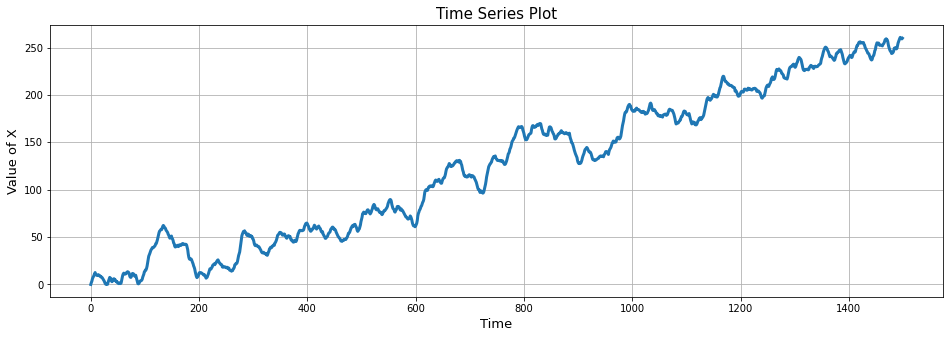

In [ ]:
plot_series(X)

This data is not stationary because we can see an upward going trend here. Such data with trends cannot be handled directly by the previous models like ARMA, AR, and MA. We will need to use differencing to remove such trends in the data first. The following content is about fitting the ARIMA model in the synthetic dataset we've just generated.




## Fitting ARIMA(p, d, q) Model

Now, we have generated the synthetic dataset, $X$. We know that the underlying data generation process is an ARIMA(3, 1, 3) model. However, for real-world datasets, we are not aware of the data generation process in advance. Thus, we follow the following steps to find a good ARIMA model to fit the data. 

\\

**Steps:**

1. **Make Data Stationary**: The ARIMA model can handle data with trends but not data with seasonality. If we can observe seasonality in the data, we need to resort to models other than ARIMA. One of which is the SARIMA model, which we'll discuss in the next chapter. If the data has trends, we can use differencing to make it stationary. Let's say the original data is $(X)$. We can sequentially apply differencing of greater order until the data becomes stationary. In other words, we can first apply the first-order differencing and check if the result is stationary. If it's not, we try second-order differencing and so on. Say the original data $(X)$ becomes stationary after d-order differencing, and the new stationary data is $X_{stationary}$. Then, we can proceed to step 2.

2. **Estimate Orders**: Plot ACF and PACF graphs for the stationary data $(X_{stationary})$. Using the graphs, estimate the upper limits $\hat{p}$ and $\hat{q}$ for the orders of AR-part and MA-part, respectively. 
    - $\hat{p}$ = the lag up to which the PACF values are significantly large.
    - $\hat{q}$ = the lag up to which the ACF values are significantly large.

3. **Fit and Select Model**: Fit ARIMA models with order (p, d, q) such that $p \in [0, \hat{p}]$ and $q \in [0, \hat{q}]$ on the original data $(X)$. Note that the model should be fitted on the original data $(X)$ and not the stationary data $(X_{stationary})$. And to select the best model out of the fitted ones, we can use the evaluation criterion to select the model. 

\\

Now, we're ready to fit an ARIMA model on the synthetic dataset. Let's explore the steps.


### Make Data Stationary

The data, as mentioned before, has an upward trend. Thus we need to remove it first. We can first apply the first-order differencing and check if the result is stationary. You can learn more about differencing and its usage in removing trend in our reading material named **Time Series Data Preprocessing**. If it's not, we try second-order differencing and so on. We can create a loop such that it stops once the data is stationary. We'll use the Augmented Dicky-Fuller (ADF) test with a p-value threshold of $0.05$ to check the data's stationarity. As discussed in the previous chapter, we can calculate the data's p_value using `adfuller` function in `statsmodels`. 


In [ ]:
p_threshold = 0.05

order_d = 0
X_diff = X.copy()

# loop to get stationary data 
while stattools.adfuller(X_diff)[1] > p_threshold:
    order_d += 1
    X_diff = tools.diff(X_diff)

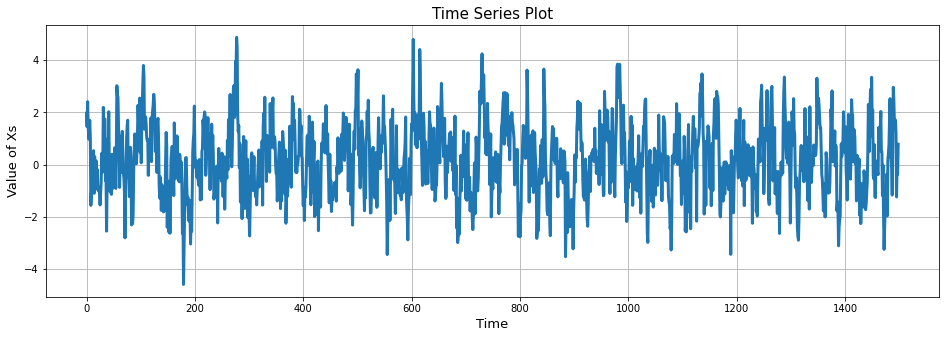

In [ ]:
X_stationary = X_diff
d = order_d
plot_series(X_stationary, y_label='Value of Xs')

Now, we have obtained a stationary data `X_stationary` and the order of differencing `d`. And the above figure shows the times series plot for this stationary data. Next, we need to estimate orders for AR and MA parts.


### Estimate Orders

We'll plot the ACF and PACF graphs for the stationary data $(X_{stationary})$ and observe the patterns of the values and use this observation to infer the rough orders for the AR and the MA parts.


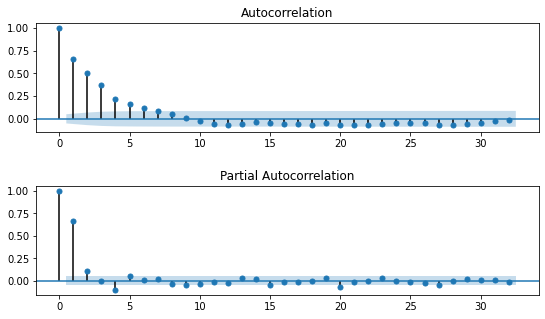

In [ ]:
def plot_graphs(X=None):
    """ Plot the PACF and ACF graphs for the time series data X

    Args:
        X (np.array): Time-series data
    """
    fig = plt.figure(figsize=(9, 5))
    fig.subplots_adjust(hspace=0.5)

    # ACF plot
    ax1 = fig.add_subplot(211)
    sm.graphics.tsa.plot_acf(X, ax=ax1)

    # PACF plot
    ax2 = fig.add_subplot(212)
    sm.graphics.tsa.plot_pacf(X, ax=ax2)
    plt.show()

plot_graphs(X=X_stationary)

Observing the ACF plot, the ACF values appear to cut off after lag 6. So we set $\hat{q}$ to 6. Similarly, from the PACF plot, the PACF values appear to cut off after lag 5, so we set $\hat{p}$ to 5.


In [ ]:
p_ = 5
q_ = 6

### Fit and Select Model

We'll use the Bayesian Information Criterion (BIC) as the evaluation metric. We can make brute force search over the ranges of orders to obtain the model with the minimum BIC value. For this, we can use `optimize.brute` from `scipy`. Know that it will take a while for the brute force search. 


In [ ]:
# minimization function
def f(order, X):
    """ Minimization function
        
        It generates a ARIMA model with provided orders and fits on the time series.
        
    Args:
        order ((int, int, int, int)): Tuple of (p, q, P, Q)
        X (np.array): Time-series data
        
    Returns:
        (float or np.inf): BIC score for the model and np.inf in case of any exception
        
    """
    p, q = order
    try:
        model = sm.tsa.ARIMA(X, order=(p, d, q)).fit()
    except ValueError:
        return np.inf
    return model.bic

# order ranges
ar_orders = slice(1, p_ + 1, 1)
ma_orders = slice(1, q_ + 1, 1)
order_ranges = (ar_orders, ma_orders)

# brute force serach
min_order = optimize.brute(f, order_ranges, args=(X,), finish=None)
min_order = min_order.astype(int)
min_order

array([1, 3])

In [ ]:
p, q = min_order

### Predictions

Let's use the model with the lowest BIC and observe the forecast made by the model against the actual data. We predict the last 100 observed time series data and future 20 values using `plot_predict` function of the fitted model.


[]

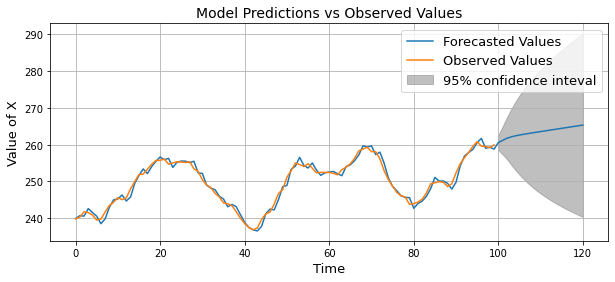

In [ ]:
model = sm.tsa.ARIMA(X, order=(p, d, q)).fit()

ax = plt.figure(figsize=(10, 4)).add_subplot(111)
model.plot_predict(len(X) - 100, len(X) + 20, dynamic=False, ax=ax, 
                   plot_insample=True)

plt.title('Model Predictions vs Observed Values', fontsize=14)
plt.xlabel('Time', fontsize=13)
plt.ylabel('Value of X', fontsize=13)
plt.legend(
    ['Forecasted Values', 'Observed Values', '95% confidence inteval'], 
    fontsize=13
)
plt.grid()
plt.plot()

The last 100 observed values of the time series are shown by the orange curve. The blue curve shows the values forecasted by the model. The dark gray region shows the 95% confidence interval for the forecasted values.


## Key Takeaways

1. If $X_t$ is generated by an ARIMA(p, d, q) process, $\nabla ^d X_t$ is generated by an ARMA(p, q) process. 

2. ARIMA models can handle data with trends. 

3. The differencing order is obtained by successive difference operations of time series data until the differenced data is stationary. 

4. The AR and MA parameters for ARIMA(p, d, q) fitted on the time series data are the same as the ARMA(p, q) model on the d differenced stationary data.
